In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ML Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Anomaly Detection Models
from sklearn.ensemble import IsolationForest
from sklearn.cluster import DBSCAN # Useful for smaller, more dense anomaly clusters
from tensorflow.keras.models import Sequential, Model # For Autoencoders (advanced)

In [2]:
# read first 600k rows (fast)
df = pd.read_csv('MUP_DPR_RY25_P04_V10_DY23_NPIBN.csv', nrows=600_000, low_memory=False)
df

,Prscrbr_NPI,Prscrbr_Last_Org_Name,Prscrbr_First_Name,Prscrbr_City,Prscrbr_State_Abrvtn,Prscrbr_State_FIPS,Prscrbr_Type,Prscrbr_Type_Src,Brnd_Name,Gnrc_Name,...,Tot_Day_Suply,Tot_Drug_Cst,Tot_Benes,GE65_Sprsn_Flag,GE65_Tot_Clms,GE65_Tot_30day_Fills,GE65_Tot_Drug_Cst,GE65_Tot_Day_Suply,GE65_Bene_Sprsn_Flag,GE65_Tot_Benes
0,1003000126,Enkeshafi,Ardalan,Bethesda,MD,24,Hospitalist,Claim-Specialty,Eliquis,Apixaban,...,437,8828.74,NaN,#,NaN,NaN,NaN,NaN,*,NaN
1,1003000126,Enkeshafi,Ardalan,Bethesda,MD,24,Hospitalist,Claim-Specialty,Prednisone,Prednisone,...,153,54.98,14.0,#,NaN,NaN,NaN,NaN,#,NaN
2,1003000142,Khalil,Rashid,Toledo,OH,39,Anesthesiology,Claim-Specialty,Acetaminophen-Codeine,Acetaminophen With Codeine,...,1020,491.38,12.0,#,NaN,NaN,NaN,NaN,*,NaN
3,1003000142,Khalil,Rashid,Toledo,OH,39,Anesthesiology,Claim-Specialty,Amitriptyline Hcl,Amitriptyline Hcl,...,1050,471.01,15.0,#,NaN,NaN,NaN,NaN,*,NaN
4,1003000142,Khalil,Rashid,Toledo,OH,39,Anesthesiology,Claim-Specialty,Baclofen,Baclofen,...,1890,796.10,23.0,NaN,27.0,29.0,417.86,870.0,*,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
599995,1023067287,James,Geoffrey,Miami,FL,12,Obstetrics & Gynecology,Claim-Specialty,Valacyclovir,Valacyclovir Hcl,...,1320,1366.89,NaN,NaN,11.0,29.0,752.82,870.0,*,NaN
599996,1023067311,Atluri,Vyjayanthi,Burr Ridge,IL,17,Geriatric Medicine,Claim-Specialty,Acetaminophen-Codeine,Acetaminophen With Codeine,...,337,449.91,NaN,NaN,13.0,13.0,449.91,337.0,*,NaN
599997,1023067311,Atluri,Vyjayanthi,Burr Ridge,IL,17,Geriatric Medicine,Claim-Specialty,Albuterol Sulfate Hfa,Albuterol Sulfate,...,1135,956.74,15.0,NaN,25.0,40.7,956.74,1135.0,NaN,15.0
599998,1023067311,Atluri,Vyjayanthi,Burr Ridge,IL,17,Geriatric Medicine,Claim-Specialty,Alendronate Sodium,Alendronate Sodium,...,1554,641.99,NaN,NaN,43.0,55.6,641.99,1554.0,*,NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600000 entries, 0 to 599999
Data columns (total 22 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Prscrbr_NPI            600000 non-null  int64  
 1   Prscrbr_Last_Org_Name  600000 non-null  object 
 2   Prscrbr_First_Name     600000 non-null  object 
 3   Prscrbr_City           600000 non-null  object 
 4   Prscrbr_State_Abrvtn   600000 non-null  object 
 5   Prscrbr_State_FIPS     600000 non-null  object 
 6   Prscrbr_Type           600000 non-null  object 
 7   Prscrbr_Type_Src       600000 non-null  object 
 8   Brnd_Name              600000 non-null  object 
 9   Gnrc_Name              600000 non-null  object 
 10  Tot_Clms               600000 non-null  int64  
 11  Tot_30day_Fills        600000 non-null  float64
 12  Tot_Day_Suply          600000 non-null  int64  
 13  Tot_Drug_Cst           600000 non-null  float64
 14  Tot_Benes              270747 non-nu

In [4]:
# Check Missing Values
print("\nMissing Value Counts:")
df.isnull().sum()


Missing Value Counts:


Prscrbr_NPI                   0
Prscrbr_Last_Org_Name         0
Prscrbr_First_Name            0
Prscrbr_City                  0
Prscrbr_State_Abrvtn          0
Prscrbr_State_FIPS            0
Prscrbr_Type                  0
Prscrbr_Type_Src              0
Brnd_Name                     0
Gnrc_Name                     0
Tot_Clms                      0
Tot_30day_Fills               0
Tot_Day_Suply                 0
Tot_Drug_Cst                  0
Tot_Benes                329253
GE65_Sprsn_Flag          333710
GE65_Tot_Clms            266290
GE65_Tot_30day_Fills     266290
GE65_Tot_Drug_Cst        266290
GE65_Tot_Day_Suply       266290
GE65_Bene_Sprsn_Flag      70757
GE65_Tot_Benes           529243
dtype: int64

In [5]:
df.describe()

,Prscrbr_NPI,Tot_Clms,Tot_30day_Fills,Tot_Day_Suply,Tot_Drug_Cst,Tot_Benes,GE65_Tot_Clms,GE65_Tot_30day_Fills,GE65_Tot_Drug_Cst,GE65_Tot_Day_Suply,GE65_Tot_Benes
count,6.000000e+05,600000.000000,600000.000000,600000.000000,6.000000e+05,270747.000000,333710.000000,333710.000000,3.337100e+05,333710.000000,70757.000000
mean,1.009889e+09,53.684233,99.231311,2789.605830,8.334423e+03,33.129124,53.552956,101.722208,8.309476e+03,2881.340802,38.535820
std,6.414140e+06,213.920907,270.759729,5657.521525,7.308851e+04,251.857724,264.268213,321.019494,8.344890e+04,6154.430470,468.471971
min,1.003000e+09,11.000000,11.000000,11.000000,0.000000e+00,11.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000
25%,1.003805e+09,15.000000,22.000000,510.000000,2.640000e+02,14.000000,14.000000,20.000000,2.337125e+02,480.000000,13.000000
50%,1.013072e+09,25.000000,42.000000,1140.000000,6.637900e+02,20.000000,22.000000,39.300000,6.207950e+02,1110.000000,19.000000
75%,1.013678e+09,52.000000,92.000000,2610.000000,2.184633e+03,35.000000,49.000000,89.000000,2.123028e+03,2526.000000,34.000000
max,1.023067e+09,94485.000000,94531.000000,302586.000000,2.678195e+07,87282.000000,87117.000000,87160.000000,2.613905e+07,287535.000000,85201.000000


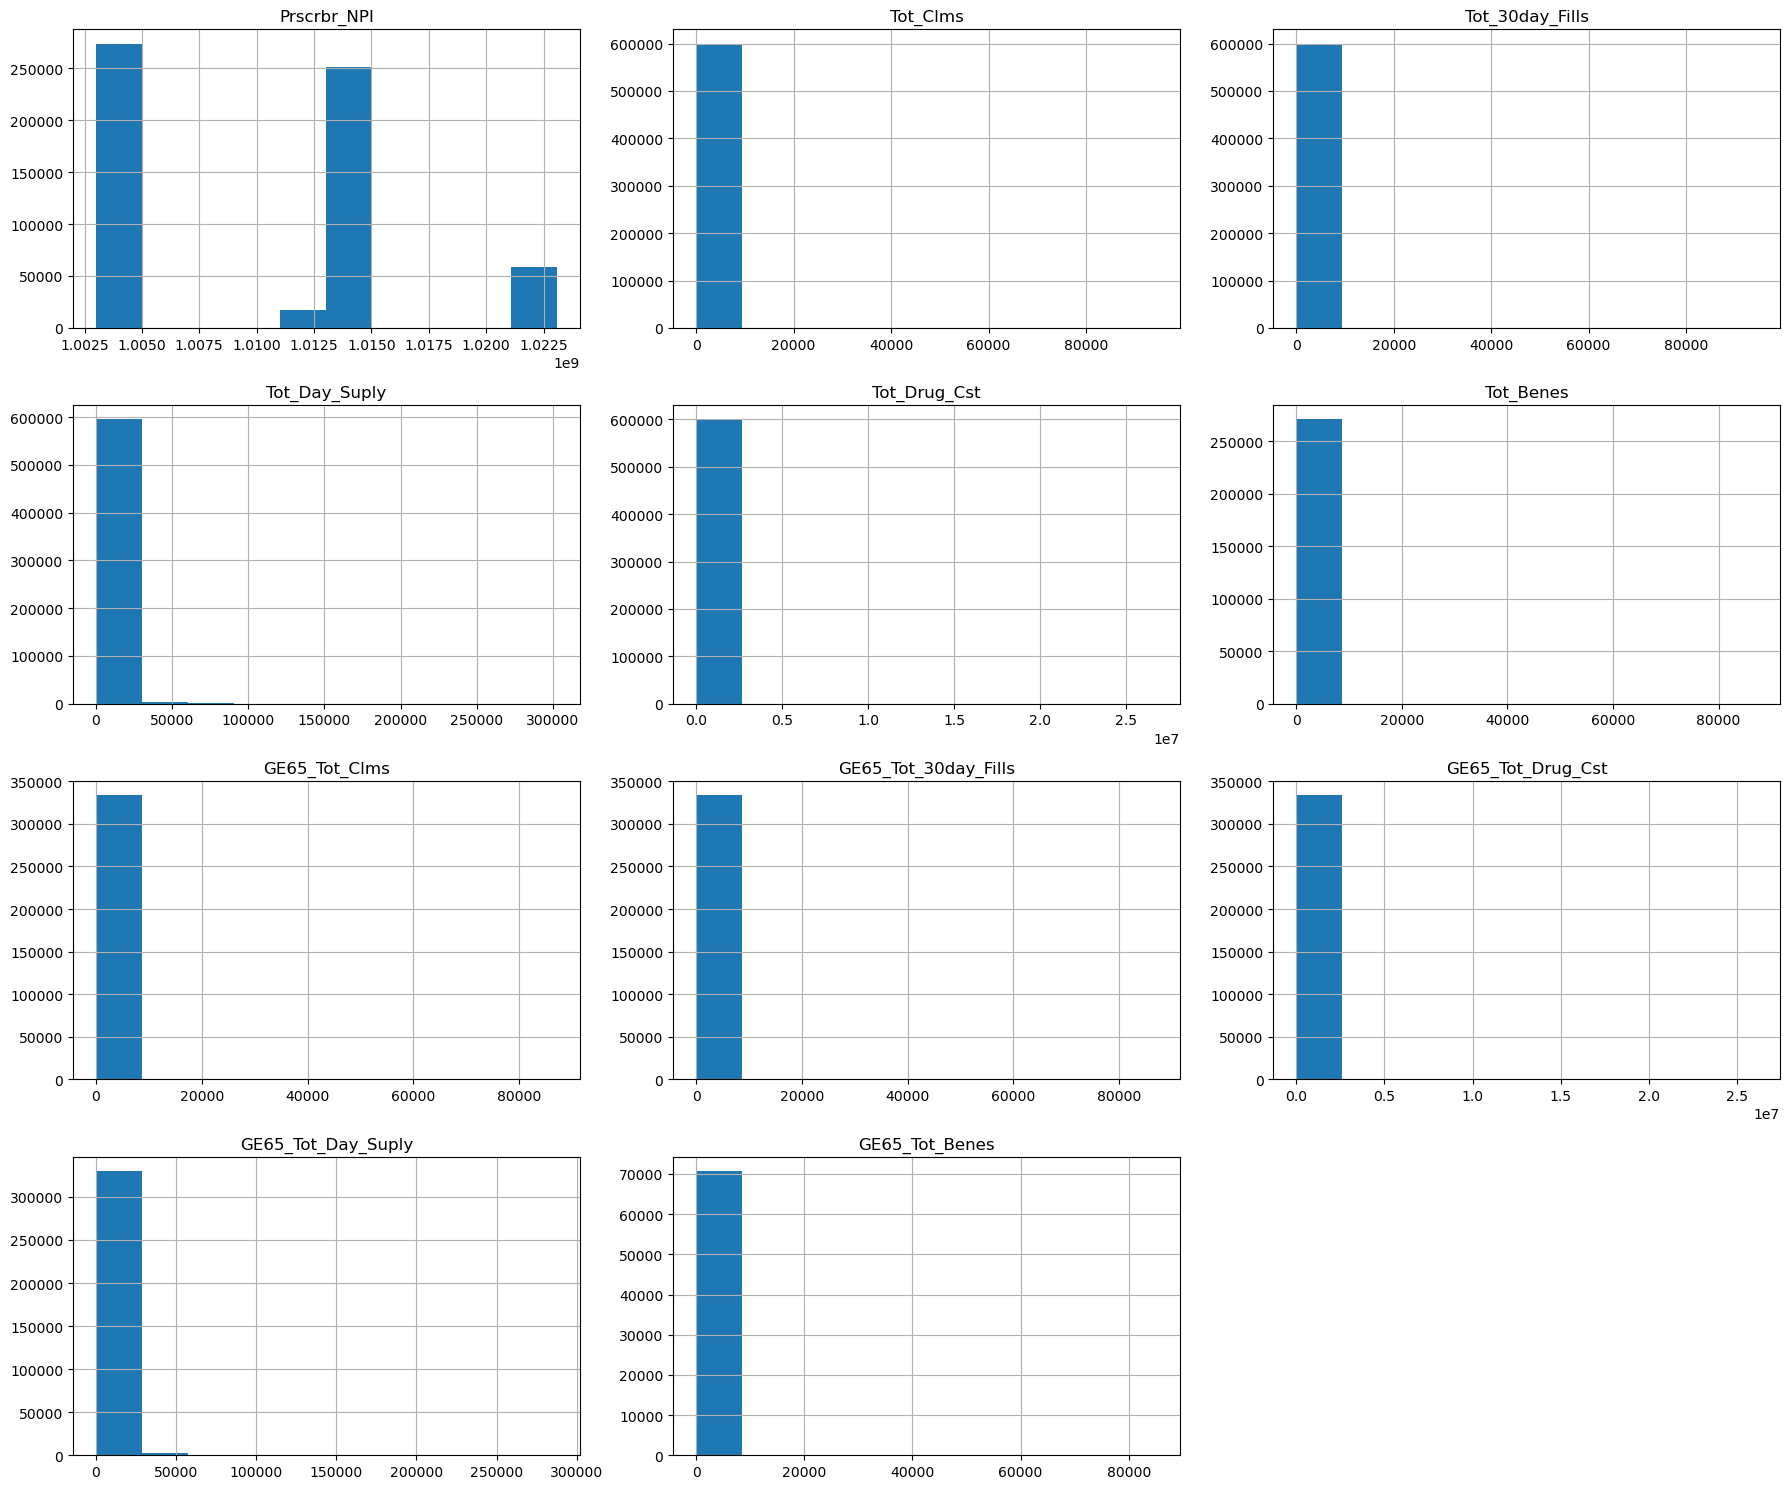

In [6]:
df.hist(figsize=(18,15))

plt.tight_layout()
plt.show()

In [7]:
df.shape

(600000, 22)

In [8]:
duplicates = df[df.duplicated(keep=False)]
duplicates

,Prscrbr_NPI,Prscrbr_Last_Org_Name,Prscrbr_First_Name,Prscrbr_City,Prscrbr_State_Abrvtn,Prscrbr_State_FIPS,Prscrbr_Type,Prscrbr_Type_Src,Brnd_Name,Gnrc_Name,...,Tot_Day_Suply,Tot_Drug_Cst,Tot_Benes,GE65_Sprsn_Flag,GE65_Tot_Clms,GE65_Tot_30day_Fills,GE65_Tot_Drug_Cst,GE65_Tot_Day_Suply,GE65_Bene_Sprsn_Flag,GE65_Tot_Benes


# Filling missing values

In [10]:
# Create missing flag (Tot_Benes)
df['Tot_Benes_missing_flag'] = df['Tot_Benes'].isnull().astype(int)

# Replace missing Tot_Benes with a random integer between 1 and 10
df['Tot_Benes'] = df['Tot_Benes'].apply(
    lambda x: np.random.randint(1, 11) if pd.isnull(x) else x
)


In [11]:
# Fill missing suppression flag (GE65_Sprsn_Flag)
df['GE65_Sprsn_Flag'].fillna('Not_Suppressed', inplace=True)

# Create binary indicator
df['GE65_Suppressed_Flag'] = np.where(df['GE65_Sprsn_Flag'] == 'Not_Suppressed', 0, 1)


In [12]:
# create missing flag for the suppressed values in G65
df['GE65_missing_flag'] = df['GE65_Tot_Clms'].isna().astype(int)


In [13]:
# Filling missing values in G65 with 0
cols_to_fill = [
    'GE65_Tot_Clms',
    'GE65_Tot_30day_Fills',
    'GE65_Tot_Drug_Cst',
    'GE65_Tot_Day_Suply'
]

df[cols_to_fill] = df[cols_to_fill].fillna(0)


In [14]:
# Fill missing suppression flag (GE65_Sprsn_Flag)
df['GE65_Bene_Sprsn_Flag'].fillna('Not_Suppressed', inplace=True)

# Create binary indicator
df['GE65_Bene_Sprsn_suppressed_Flag'] = np.where(df['GE65_Bene_Sprsn_Flag'] == 'Not_Suppressed', 0, 1)


In [15]:
# Create suppression flag (1 if suppressed, 0 otherwise)
df['GE65_Bene_Suppressed'] = np.where(df['GE65_Tot_Benes'].isna(), 1, 0)

# Impute missing values conservatively (CMS suppression implies <11)
# Median of small non-suppressed values is usually safe
median_small_value = df.loc[df['GE65_Tot_Benes'].between(1, 10, inclusive="both"), 'GE65_Tot_Benes'].median()

# If no small values exist, default to 5 (midpoint of 1–10)
fill_value = median_small_value if not np.isnan(median_small_value) else 5

# Fill suppressed rows
df['GE65_Tot_Benes'] = df['GE65_Tot_Benes'].fillna(fill_value)

# Feature engineering

In [17]:
df.columns

Index(['Prscrbr_NPI', 'Prscrbr_Last_Org_Name', 'Prscrbr_First_Name',
       'Prscrbr_City', 'Prscrbr_State_Abrvtn', 'Prscrbr_State_FIPS',
       'Prscrbr_Type', 'Prscrbr_Type_Src', 'Brnd_Name', 'Gnrc_Name',
       'Tot_Clms', 'Tot_30day_Fills', 'Tot_Day_Suply', 'Tot_Drug_Cst',
       'Tot_Benes', 'GE65_Sprsn_Flag', 'GE65_Tot_Clms', 'GE65_Tot_30day_Fills',
       'GE65_Tot_Drug_Cst', 'GE65_Tot_Day_Suply', 'GE65_Bene_Sprsn_Flag',
       'GE65_Tot_Benes', 'Tot_Benes_missing_flag', 'GE65_Suppressed_Flag',
       'GE65_missing_flag', 'GE65_Bene_Sprsn_suppressed_Flag',
       'GE65_Bene_Suppressed'],
      dtype='object')

In [18]:
# Very high values → inflated billing
df['Avg_Cost_per_Claim']= df['Tot_Drug_Cst'] / df['Tot_Clms']
# Very high → possible phantom claims
df['Cost_per_Beneficiary']=	df['Tot_Drug_Cst'] / df['Tot_Benes']
# Extremely high → overprescribing
df['Claims_per_Beneficiary']= df['Tot_Clms'] / df['Tot_Benes']
# Longer than typical → potential diversion
df['Avg_Days_Supply_per_Claim']= df['Tot_Day_Suply'] / df['Tot_Clms']
# Detects abnormally costly daily treatment
df['Cost_per_Day']=	df['Tot_Drug_Cst'] / df['Tot_Day_Suply']

# High risk drugs containing opoids
opioids = ["FENTANYL", "FENTANYL CITRATE", "MORPHINE", "MORPHINE SULFATE", "MORPHINE SULFATE/NALTREXONE",
    "HYDROMORPHONE", "HYDROMORPHONE HCL", "METHADONE", "METHADONE HCL",
    "OXYCODONE", "OXYCODONE HCL", "OXYCODONE HCL/ACETAMINOPHEN", "OXYCODONE HCL/ASPIRIN",
    "OXYMORPHONE", "OXYMORPHONE HCL",
    "HYDROCODONE", "HYDROCODONE/ACETAMINOPHEN", "HYDROCODONE/IBUPROFEN", "HYDROCODONE BITARTRATE",
    "CODEINE", "CODEINE SULFATE", "CODEINE/BUTALBITAL", "ACETAMINOPHEN WITH CODEINE",
    "TRAMADOL", "TRAMADOL HCL", "TRAMADOL HCL/ACETAMINOPHEN",
    "BUPRENORPHINE", "BUPRENORPHINE HCL",
    "MOPERIDINE", "MEPERIDINE", "MEPERIDINE HCL",   # sometimes spelled MEPERIDINE
    "TAPENTADOL",
    "LEVORPHANOL", "PENTAZOCINE", "BUTORPHANOL", "OPIUM", "MORPHINE/...", "CARISOPRODOL/.*CODEINE"]
df['Opioid_Flag'] = df['Gnrc_Name'].str.upper().isin(opioids).astype(int)

# Drugs containing antiobiotics
antibiotics= ["DOXYCYCLINE MONOHYDRATE", "RIFAMYCIN SODIUM", "AMIKACIN SULFATE", "AMOXICILLIN/POTASSIUM CLAV",
    "AMOXICILLIN", "AMPICILLIN SODIUM", "AMPICILLIN TRIHYDRATE", "AMPICILLIN SOD/SULBACTAM SOD",
    "AMIKACIN LIPOSOMAL/NEB.ACCESSR", "MOXIFLOXACIN HCL", "MOXIFLOXACIN IN NACL (ISO-OSM)",
    "CEFTAZIDIME/AVIBACTAM", "AZTREONAM", "AZITHROMYCIN", "SULFAMETHOXAZOLE/TRIMETHOPRIM",
    "DELAFLOXACIN MEGLUMINE", "CLARITHROMYCIN", "PEN G BENZ/PEN G PROCAINE", "PENICILLIN G BENZATHINE",
    "CEFTIBUTEN", "CEFACLOR", "CEFADROXIL", "CEFAZOLIN SODIUM", "CEFDINIR", "CEFEPIME HCL", "CEFIXIME",
    "CEFOTETAN DISODIUM", "CEFOXITIN SODIUM", "CEFPODOXIME PROXETIL", "CEFPROZIL", "CEFTAZIDIME",
    "CEFUROXIME AXETIL", "CEFTRIAXONE SODIUM", "CEPHALEXIN", "CIPROFLOXACIN", "CLINDAMYCIN HCL",
    "DAPTOMYCIN", "DALBAVANCIN HCL", "DEMECLOCYCLINE HCL", "DICLOXACILLIN SODIUM", "FIDAXOMICIN",
    "DORIPENEM", "DOXYCYCLINE HYCLATE", "ERYTHROMYCIN ETHYLSUCCINATE", "ERTAPENEM SODIUM",
    "ERYTHROMYCIN BASE", "GEMIFLOXACIN MESYLATE", "VANCOMYCIN HCL", "METRONIDAZOLE",
    "FOSFOMYCIN TROMETHAMINE", "NITROFURANTOIN", "GENTAMICIN SULFATE", "IMIPENEM/CILASTATIN SODIUM",
    "TELITHROMYCIN", "ORITAVANCIN DIPHOSPHATE", "LEVOFLOXACIN", "LINCOMYCIN HCL", "LINEZOLID",
    "MINOCYCLINE HCL", "NAFCILLIN SODIUM", "NEOMYCIN SULFATE", "NORFLOXACIN", "OMADACYCLINE TOSYLATE",
    "OFLOXACIN", "OXACILLIN SODIUM", "PENICILLIN G POTASSIUM", "PENICILLIN V POTASSIUM",
    "PIPERACILLIN SODIUM/TAZOBACTAM", "TRIMETHOPRIM", "SARECYCLINE HCL", "TEDIZOLID PHOSPHATE",
    "SECNIDAZOLE", "STREPTOMYCIN SULFATE", "SULFADIAZINE", "QUINUPRISTIN/DALFOPRISTIN",
    "CEFTAROLINE FOSAMIL ACETATE", "TETRACYCLINE HCL", "TIGECYCLINE", "TINIDAZOLE", "TOBRAMYCIN",
    "MEROPENEM", "VANCOMYCIN HCL", "TELAVANCIN HCL", "LEFAMULIN ACETATE", "ERAVACYCLINE DI-HYDROCHLORIDE",
    "RIFAXIMIN", "PLAZOMICIN SULFATE", "CEFTOLOZANE/TAZOBACTAM"]
df['Antibiotics_Flag'] = df['Gnrc_Name'].str.upper().isin(antibiotics).astype(int)

# Long acting opoid drugs (LA opioids drugs)
la_opioids= ["MORPHINE SULFATE", "BUPRENORPHINE HCL", "BUPRENORPHINE", "TRAMADOL HCL",
    "METHADONE HCL", "FENTANYL", "MORPHINE SULFATE/NALTREXONE", "HYDROMORPHONE HCL",
    "HYDROCODONE BITARTRATE", "LEVORPHANOL TARTRATE", "TAPENTADOL HCL",
    "OXYMORPHONE HCL", "OXYCODONE HCL", "OXYCODONE HCL/ACETAMINOPHEN",
    "OXYCODONE MYRISTATE"]
df['la_Opioid_Flag'] = df['Gnrc_Name'].str.upper().isin(la_opioids).astype(int)

# Antipsychootic flags
antipsychotics= ["ARIPIPRAZOLE", "ARIPIPRAZOLE LAUROXIL", "ARIPIPRAZOLE LAUROXIL,SUBMICR.",
    "ASENAPINE MALEATE", "LUMATEPERONE TOSYLATE", "CHLORPROMAZINE HCL",
    "CLOZAPINE", "ILOPERIDONE", "FLUPHENAZINE DECANOATE", "FLUPHENAZINE HCL",
    "ZIPRASIDONE HCL", "ZIPRASIDONE MESYLATE", "HALOPERIDOL LACTATE",
    "HALOPERIDOL DECANOATE", "HALOPERIDOL", "PALIPERIDONE", "PALIPERIDONE PALMITATE",
    "LURASIDONE HCL", "LOXAPINE SUCCINATE", "OLANZAPINE/SAMIDORPHAN MALATE",
    "MOLINDONE HCL", "PIMAVANSERIN TARTRATE", "OLANZAPINE", "OLANZAPINE/FLUOXETINE HCL",
    "PIMOZIDE", "PERPHENAZINE", "PERPHENAZINE/AMITRIPTYLINE HCL", "RISPERIDONE",
    "RISPERIDONE MICROSPHERES", "QUETIAPINE FUMARATE", "BREXPIPRAZOLE",
    "ASENAPINE", "THIORIDAZINE HCL", "THIOTHIXENE", "TRIFLUOPERAZINE HCL",
    "CARIPRAZINE HCL", "OLANZAPINE PAMOATE"]
df['Antipsychotic_Flag'] = df['Gnrc_Name'].str.upper().isin(antipsychotics).astype(int)

ndc_conflict=["ACETAMINOPHEN/CAFF/DIHYDROCOD","ARIPIPRAZOLE","AZTREONAM LYSINE","BUPRENORPHINE",
    "BUPRENORPHINE HCL","BUTORPHANOL TARTRATE","FENTANYL","FENTANYL CITRATE","LEVORPHANOL TARTRATE",
    "MEPERIDINE HCL","MOLINDONE HCL","MORPHINE SULFATE","OPIUM/BELLADONNA ALKALOIDS","OXYCODONE HCL",
    "PENTAZOCINE HCL/NALOXONE HCL","TOBRAMYCIN","TOBRAMYCIN IN 0.225% NACL","TOPIRAMATE"]
df['NDC_conflict_Flag'] = df['Gnrc_Name'].str.upper().isin(ndc_conflict).astype(int)

In [19]:
# Total brand claims 
brand_claims = (
    df[df['Brnd_Name'].notna()]
    .groupby('Prscrbr_NPI')['Tot_Clms']
    .sum()
    .rename('Total_Claims_Brand')
)

df = df.merge(brand_claims, on='Prscrbr_NPI', how='left')

# Total Drug Cost for Brand Drugs per prescriber ---
brand_costs = (
    df[df['Brnd_Name'].notna()]
    .groupby('Prscrbr_NPI')['Tot_Drug_Cst']
    .sum()
    .rename('Total_Cost_Brand')
)

# merge back into main dataframe
df = df.merge(brand_costs, on='Prscrbr_NPI', how='left')

# optional: replace NaN with 0 for prescribers with no brand claims
df['Total_Claims_Brand'] = df['Total_Claims_Brand'].fillna(0)
df['Total_Cost_Brand']   = df['Total_Cost_Brand'].fillna(0)

# quick sanity-check
print(df[['Prscrbr_NPI','Total_Claims_Brand','Total_Cost_Brand']].drop_duplicates().head())




    Prscrbr_NPI  Total_Claims_Brand  Total_Cost_Brand
0    1003000126                  27           8883.72
2    1003000142                1769          54440.25
23   1003000167                  71            190.08
25   1003000423                  58           5670.27
27   1003000480                  28            409.70


In [20]:
# Total Claims for Generic Drugs per prescriber ---
generic_claims = (
    df[df['Gnrc_Name'].notna()]
    .groupby('Prscrbr_NPI')['Tot_Clms']
    .sum()
    .rename('Total_Claims_Generic')
)

# Total Drug Cost for Generic Drugs per prescriber ---
generic_costs = (
    df[df['Gnrc_Name'].notna()]
    .groupby('Prscrbr_NPI')['Tot_Drug_Cst']
    .sum()
    .rename('Total_Cost_Generic')
)

# merge back into main dataframe
df = df.merge(generic_claims, on='Prscrbr_NPI', how='left')
df = df.merge(generic_costs, on='Prscrbr_NPI', how='left')

df['Total_Claims_Generic'] = df['Total_Claims_Generic'].fillna(0)
df['Total_Cost_Generic']   = df['Total_Cost_Generic'].fillna(0)

print(df[['Prscrbr_NPI','Total_Claims_Generic','Total_Cost_Generic']].drop_duplicates().head())

    Prscrbr_NPI  Total_Claims_Generic  Total_Cost_Generic
0    1003000126                    27             8883.72
2    1003000142                  1769            54440.25
23   1003000167                    71              190.08
25   1003000423                    58             5670.27
27   1003000480                    28              409.70


In [21]:
# Total_Claims_Antibiotic (Make sure flag is boolean/int)
df['Antibiotics_Flag'] = df['Antibiotics_Flag'].astype(int)

antibiotic_claims = (
    df[df['Antibiotics_Flag'] == 1]
    .groupby('Prscrbr_NPI')['Tot_Clms']
    .sum()
    .rename('Total_Claims_Antibiotic')
)

antibiotic_costs = (
    df[df['Antibiotics_Flag'] == 1]
    .groupby('Prscrbr_NPI')['Tot_Drug_Cst']
    .sum()
    .rename('Total_Cost_Antibiotic')
)

# Total beneficiaries receiving antibiotics per prescriber (appears on every row for that prescriber)
antibiotic_benes = (
    df[df['Antibiotics_Flag'] == 1]
      .groupby('Prscrbr_NPI')['Tot_Benes']
      .sum()
      .rename('Total_Benes_Antibiotic')
)

df = df.merge(antibiotic_claims, on='Prscrbr_NPI', how='left')
df = df.merge(antibiotic_costs, on='Prscrbr_NPI', how='left')
df = df.merge(antibiotic_benes, on='Prscrbr_NPI', how='left')

df['Total_Claims_Antibiotic'] = df['Total_Claims_Antibiotic'].fillna(0)
df['Total_Cost_Antibiotic']   = df['Total_Cost_Antibiotic'].fillna(0)
df['Total_Benes_Antibiotic']  = df['Total_Benes_Antibiotic'].fillna(0)

# show one row per prescriber
print(
    df[['Prscrbr_NPI','Total_Claims_Antibiotic','Total_Cost_Antibiotic', 'Total_Benes_Antibiotic']]
    .drop_duplicates()
    .head(10)
)


     Prscrbr_NPI  Total_Claims_Antibiotic  Total_Cost_Antibiotic  \
0     1003000126                      0.0                   0.00   
2     1003000142                      0.0                   0.00   
23    1003000167                     51.0                 152.04   
25    1003000423                      0.0                   0.00   
27    1003000480                      0.0                   0.00   
29    1003000530                     83.0                 871.57   
144   1003000597                    187.0                2974.02   
162   1003000720                    155.0                2325.57   
173   1003000738                      0.0                   0.00   
175   1003000746                      0.0                   0.00   

     Total_Benes_Antibiotic  
0                       0.0  
2                       0.0  
23                     43.0  
25                      0.0  
27                      0.0  
29                     75.0  
144                   147.0  
162        

In [22]:
# --- 1) Total Claims for Antipsychotic Drugs (Age 65+)
GE65_antipsychotic_claims = (
    df[df['Antipsychotic_Flag'] == 1]
    .groupby('Prscrbr_NPI')['GE65_Tot_Clms']
    .sum()
    .rename('GE65_Total_Claims_Antipsychotic')
)

# --- 2) Total Drug Cost for Antipsychotic Drugs (Age 65+)
GE65_antipsychotic_total_cost = (
    df[df['Antipsychotic_Flag'] == 1]
    .groupby('Prscrbr_NPI')['GE65_Tot_Drug_Cst']
    .sum()
    .rename('GE65_Total_Cost_Antipsychotic')
)

# --- 3) Total Beneficiaries for Antipsychotic Drugs (Age 65+)
GE65_antipsychotic_benes = (
    df[df['Antipsychotic_Flag'] == 1]
    .groupby('Prscrbr_NPI')['GE65_Tot_Benes']
    .sum()
    .rename('GE65_Total_Benes_Antipsychotic')
)

# Merge all three into df
df = df.merge(GE65_antipsychotic_claims, on='Prscrbr_NPI', how='left')
df = df.merge(GE65_antipsychotic_total_cost, on='Prscrbr_NPI', how='left')
df = df.merge(GE65_antipsychotic_benes, on='Prscrbr_NPI', how='left')

# Fill NaN for prescribers without any antipsychotic claims
df['GE65_Total_Claims_Antipsychotic'] = df['GE65_Total_Claims_Antipsychotic'].fillna(0)
df['GE65_Total_Cost_Antipsychotic'] = df['GE65_Total_Cost_Antipsychotic'].fillna(0)
df['GE65_Total_Benes_Antipsychotic'] = df['GE65_Total_Benes_Antipsychotic'].fillna(0)

# --- 5) Quick validation
print(
    df[['Prscrbr_NPI',
        'GE65_Total_Claims_Antipsychotic',
        'GE65_Total_Cost_Antipsychotic',
        'GE65_Total_Benes_Antipsychotic']]
      .drop_duplicates()
      .head(10)
)

     Prscrbr_NPI  GE65_Total_Claims_Antipsychotic  \
0     1003000126                              0.0   
2     1003000142                              0.0   
23    1003000167                              0.0   
25    1003000423                              0.0   
27    1003000480                              0.0   
29    1003000530                              0.0   
144   1003000597                              0.0   
162   1003000720                              0.0   
173   1003000738                              0.0   
175   1003000746                              0.0   

     GE65_Total_Cost_Antipsychotic  GE65_Total_Benes_Antipsychotic  
0                              0.0                             0.0  
2                              0.0                             0.0  
23                             0.0                             0.0  
25                             0.0                             0.0  
27                             0.0                             0.0  
29

In [23]:
# 1. TOTALS FOR OPIOID DRUGS
# ==========================================================
df['Total_Claims_Opioid'] = (
    df.loc[df['Opioid_Flag'] == 1, ['Prscrbr_NPI', 'Tot_Clms']]
      .groupby('Prscrbr_NPI')['Tot_Clms']
      .transform('sum')
)

df['Total_Cost_Opioid'] = (
    df.loc[df['Opioid_Flag'] == 1, ['Prscrbr_NPI', 'Tot_Drug_Cst']]
      .groupby('Prscrbr_NPI')['Tot_Drug_Cst']
      .transform('sum')
)

df['Total_Benes_Opioid'] = (
    df.loc[df['Opioid_Flag'] == 1, ['Prscrbr_NPI', 'Tot_Benes']]
      .groupby('Prscrbr_NPI')['Tot_Benes']
      .transform('sum')
)

# Fill NaN for prescribers with no opioid claims
df[['Total_Claims_Opioid','Total_Cost_Opioid','Total_Benes_Opioid']] = (
    df[['Total_Claims_Opioid','Total_Cost_Opioid','Total_Benes_Opioid']].fillna(0)
)

# ==========================================================
# 2. TOTALS FOR LONG-ACTING (LA) OPIOID DRUGS
# ==========================================================
df['Total_Claims_LA_Opioid'] = (
    df.loc[df['la_Opioid_Flag'] == 1, ['Prscrbr_NPI', 'Tot_Clms']]
      .groupby('Prscrbr_NPI')['Tot_Clms']
      .transform('sum')
)

df['Total_Cost_LA_Opioid'] = (
    df.loc[df['la_Opioid_Flag'] == 1, ['Prscrbr_NPI', 'Tot_Drug_Cst']]
      .groupby('Prscrbr_NPI')['Tot_Drug_Cst']
      .transform('sum')
)

df['Total_Benes_LA_Opioid'] = (
    df.loc[df['la_Opioid_Flag'] == 1, ['Prscrbr_NPI', 'Tot_Benes']]
      .groupby('Prscrbr_NPI')['Tot_Benes']
      .transform('sum')
)

df[['Total_Claims_LA_Opioid','Total_Cost_LA_Opioid','Total_Benes_LA_Opioid']] = (
    df[['Total_Claims_LA_Opioid','Total_Cost_LA_Opioid','Total_Benes_LA_Opioid']].fillna(0)
)

# Quick validation
print(
    df[['Prscrbr_NPI',
        'Total_Claims_Opioid','Total_Cost_Opioid','Total_Benes_Opioid',
        'Total_Claims_LA_Opioid','Total_Cost_LA_Opioid','Total_Benes_LA_Opioid']]
      .drop_duplicates()
      .head(10)
)

    Prscrbr_NPI  Total_Claims_Opioid  Total_Cost_Opioid  Total_Benes_Opioid  \
0    1003000126                  0.0               0.00                 0.0   
2    1003000142                824.0           21384.93               375.0   
3    1003000142                  0.0               0.00                 0.0   
5    1003000142                824.0           21384.93               375.0   
23   1003000167                  0.0               0.00                 0.0   
25   1003000423                  0.0               0.00                 0.0   
27   1003000480                  0.0               0.00                 0.0   
28   1003000480                 12.0              25.58                12.0   
29   1003000530                  0.0               0.00                 0.0   
80   1003000530                 50.0            1001.44                12.0   

    Total_Claims_LA_Opioid  Total_Cost_LA_Opioid  Total_Benes_LA_Opioid  
0                      0.0                  0.00        

# Feature Preprocessing Pipeline

In [25]:
# Define numerical and categorical features for the ML model

# Define feature groups
num_features = [
    'Tot_Clms', 'Tot_30day_Fills', 'Tot_Day_Suply', 'Tot_Drug_Cst',
    'Tot_Benes', 'GE65_Tot_Clms', 'GE65_Tot_30day_Fills', 'GE65_Tot_Drug_Cst',
    'GE65_Tot_Day_Suply', 'GE65_Tot_Benes',
    'Avg_Cost_per_Claim', 'Cost_per_Beneficiary', 'Claims_per_Beneficiary',
    'Avg_Days_Supply_per_Claim', 'Cost_per_Day',
    'Total_Claims_Brand', 'Total_Cost_Brand',
    'Total_Claims_Generic', 'Total_Cost_Generic',
    'Total_Claims_Antibiotic', 'Total_Cost_Antibiotic',
    'Total_Benes_Antibiotic', 'GE65_Total_Claims_Antipsychotic',
    'GE65_Total_Cost_Antipsychotic', 'GE65_Total_Benes_Antipsychotic',
    'Total_Claims_Opioid', 'Total_Cost_Opioid', 'Total_Benes_Opioid',
    'Total_Claims_LA_Opioid', 'Total_Cost_LA_Opioid', 'Total_Benes_LA_Opioid'
]

    
cat_features = [ 
    'Prscrbr_Type', 'Prscrbr_Type_Src', 'Prscrbr_State_Abrvtn', 'GE65_Sprsn_Flag', 'GE65_Bene_Sprsn_Flag'
]

bin_features = [
    'Tot_Benes_missing_flag', 'GE65_Suppressed_Flag', 'GE65_missing_flag',
    'GE65_Bene_Sprsn_suppressed_Flag', 'GE65_Bene_Suppressed',
    'Opioid_Flag', 'Antibiotics_Flag', 'la_Opioid_Flag',
    'Antipsychotic_Flag', 'NDC_conflict_Flag'
]

# Build Preprocessing Pipelines

In [27]:
# Define transformers
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Combine into column transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_features),
        ('cat', cat_transformer, cat_features),
        ('bin', 'passthrough', bin_features)
    ]
)
# Applying the transformations
X_processed = preprocessor.fit_transform(df)
print(f"Processed data shape: {X_processed.shape}")

Processed data shape: (600000, 204)


In [28]:
df.columns

Index(['Prscrbr_NPI', 'Prscrbr_Last_Org_Name', 'Prscrbr_First_Name',
       'Prscrbr_City', 'Prscrbr_State_Abrvtn', 'Prscrbr_State_FIPS',
       'Prscrbr_Type', 'Prscrbr_Type_Src', 'Brnd_Name', 'Gnrc_Name',
       'Tot_Clms', 'Tot_30day_Fills', 'Tot_Day_Suply', 'Tot_Drug_Cst',
       'Tot_Benes', 'GE65_Sprsn_Flag', 'GE65_Tot_Clms', 'GE65_Tot_30day_Fills',
       'GE65_Tot_Drug_Cst', 'GE65_Tot_Day_Suply', 'GE65_Bene_Sprsn_Flag',
       'GE65_Tot_Benes', 'Tot_Benes_missing_flag', 'GE65_Suppressed_Flag',
       'GE65_missing_flag', 'GE65_Bene_Sprsn_suppressed_Flag',
       'GE65_Bene_Suppressed', 'Avg_Cost_per_Claim', 'Cost_per_Beneficiary',
       'Claims_per_Beneficiary', 'Avg_Days_Supply_per_Claim', 'Cost_per_Day',
       'Opioid_Flag', 'Antibiotics_Flag', 'la_Opioid_Flag',
       'Antipsychotic_Flag', 'NDC_conflict_Flag', 'Total_Claims_Brand',
       'Total_Cost_Brand', 'Total_Claims_Generic', 'Total_Cost_Generic',
       'Total_Claims_Antibiotic', 'Total_Cost_Antibiotic',
       'Tot

# Model Training: Unsupervised Anomaly Detection

In [30]:
# Isolation Forest 
# Transform features
X_processed = preprocessor.fit_transform(df)

# IF hyperparams
CONTAMINATION_RATE = 0.01
iso_forest = IsolationForest(
    n_estimators=100,
    contamination=CONTAMINATION_RATE,
    random_state=42,
    n_jobs=-1,
    max_samples="auto"
)

# Train
iso_forest.fit(X_processed)

# Predict labels (-1 anomaly, 1 normal)
labels = iso_forest.predict(X_processed)
df["is_anomaly_if"] = np.where(labels == -1, 1, 0)

# Invert scores so that higher = more anomalous
if_scores = -iso_forest.decision_function(X_processed)

# Normalize to [0,1] for dashboard and readability
if_min, if_max = np.min(if_scores), np.max(if_scores)
if if_max > if_min:
    if_norm = (if_scores - if_min) / (if_max - if_min)
else:
    if_norm = np.zeros_like(if_scores)

df["iso_score"] = if_norm

# Dashboard compatibility fields
df["ensemble_score"] = df["iso_score"]
df["is_anomaly_ensemble"] = df["is_anomaly_if"]

# -------- Console Summary Output --------
anomaly_count = df["is_anomaly_if"].sum()
anomaly_rate = anomaly_count / df.shape[0] * 100

print(f"\nIsolation Forest Training Completed")
print(f"Total Records: {df.shape[0]:,}")
print(f"Flagged as Anomaly: {anomaly_count:,}")
print(f"Anomaly Rate: {anomaly_rate:.2f}%")

# Top anomalies (for console visibility) in the prescriber dataset
top_anomalies = (
    df.sort_values("iso_score", ascending=False)
      .head(10)
      .loc[:, [
          "Prscrbr_NPI",           # Prescriber identifier
          "Prscrbr_Last_Org_Name", # Organization / clinic
          "Prscrbr_First_Name",    # Prescriber first name
          "Prscrbr_State_Abrvtn",  # State
          "Gnrc_Name",             # Generic drug name
          "Brnd_Name",             # Brand name
          "Tot_Drug_Cst",          # Total drug cost
          "Tot_Clms",              # Total claims
          "iso_score",              # Anomaly score
          'Tot_Benes',
          'Tot_Clms',
          'GE65_Tot_Benes',
          'Opioid_Flag',            # High risk drug
          'Antibiotics_Flag', 'la_Opioid_Flag',
          'Antipsychotic_Flag', 'NDC_conflict_Flag', 'Prscrbr_City'          
      ]]
)

# Display top anomalies
top_anomalies

print("\nTop 10 Most Anomalous Transactions (Highest Score):\n")
#print(top_anomalies.to_string(index=False))
top_anomalies


Isolation Forest Training Completed
Total Records: 600,000
Flagged as Anomaly: 6,000
Anomaly Rate: 1.00%

Top 10 Most Anomalous Transactions (Highest Score):



,Prscrbr_NPI,Prscrbr_Last_Org_Name,Prscrbr_First_Name,Prscrbr_State_Abrvtn,Gnrc_Name,Brnd_Name,Tot_Drug_Cst,Tot_Clms,iso_score,Tot_Benes,Tot_Clms,GE65_Tot_Benes,Opioid_Flag,Antibiotics_Flag,la_Opioid_Flag,Antipsychotic_Flag,NDC_conflict_Flag,Prscrbr_City
564648,1023021409,Rasquinha,Clemencia,MN,Apixaban,Eliquis,1037421.88,2547,1.000000,366.0,2547,332.0,0,0,0,0,0,Golden Valley
325217,1013141951,Azzam,Mohannad,AL,Apixaban,Eliquis,609504.06,2060,0.907605,307.0,2060,259.0,0,0,0,0,0,Hoover
564551,1023021409,Rasquinha,Clemencia,MN,Atorvastatin Calcium,Atorvastatin Calcium,63774.08,4858,0.902464,758.0,4858,656.0,0,0,0,0,0,Golden Valley
183251,1003840778,Mays,Ruth,MI,Rsvpref3 Antigen/As01e/Pf,Arexvy,26781952.98,87363,0.891066,87282.0,87363,85201.0,0,0,0,0,0,Highland Park
564745,1023021409,Rasquinha,Clemencia,MN,Levothyroxine Sodium,Levothyroxine Sodium,47441.07,3961,0.890894,622.0,3961,560.0,0,0,0,0,0,Golden Valley
564678,1023021409,Rasquinha,Clemencia,MN,Gabapentin,Gabapentin,49825.43,3530,0.890894,613.0,3530,508.0,0,0,0,0,0,Golden Valley
564906,1023021409,Rasquinha,Clemencia,MN,Tramadol Hcl,Tramadol Hcl,4847.62,671,0.888472,195.0,671,178.0,1,0,1,0,0,Golden Valley
183278,1003840778,Mays,Ruth,MI,Varicella-Zoster Ge/As01b/Pf,Shingrix,19862186.15,94485,0.887199,66000.0,94485,60479.0,0,0,0,0,0,Highland Park
564540,1023021409,Rasquinha,Clemencia,MN,Amlodipine Besylate,Amlodipine Besylate,26668.44,3109,0.880756,530.0,3109,490.0,0,0,0,0,0,Golden Valley
564777,1023021409,Rasquinha,Clemencia,MN,Metoprolol Succinate,Metoprolol Succinate,36895.94,2603,0.880756,451.0,2603,430.0,0,0,0,0,0,Golden Valley


In [83]:
df[["Prscrbr_NPI", "Prscrbr_Last_Org_Name", "Prscrbr_First_Name",
    "Prscrbr_State_Abrvtn", "Prscrbr_City", "Gnrc_Name", "Brnd_Name",
    "Tot_Clms", "Tot_Drug_Cst", "Tot_Benes", "GE65_Tot_Benes",
    "Opioid_Flag", "Antibiotics_Flag", "la_Opioid_Flag", "Antipsychotic_Flag",
    "NDC_conflict_Flag", "iso_score"]].tail(60)

,Prscrbr_NPI,Prscrbr_Last_Org_Name,Prscrbr_First_Name,Prscrbr_State_Abrvtn,Prscrbr_City,Gnrc_Name,Brnd_Name,Tot_Clms,Tot_Drug_Cst,Tot_Benes,GE65_Tot_Benes,Opioid_Flag,Antibiotics_Flag,la_Opioid_Flag,Antipsychotic_Flag,NDC_conflict_Flag,iso_score
599940,1023067147,Brkic-Vukotic,Ognjenka,GA,Roswell,Metoprolol Tartrate,Metoprolol Tartrate,40,331.09,11.0,5.0,0,0,0,0,0,0.053443
599941,1023067147,Brkic-Vukotic,Ognjenka,GA,Roswell,Mirtazapine,Mirtazapine,12,337.39,7.0,5.0,0,0,0,0,0,0.037055
599942,1023067147,Brkic-Vukotic,Ognjenka,GA,Roswell,Montelukast Sodium,Montelukast Sodium,61,1023.23,22.0,22.0,0,0,0,0,0,0.143524
599943,1023067147,Brkic-Vukotic,Ognjenka,GA,Roswell,Mirabegron,Myrbetriq,14,8565.58,5.0,5.0,0,0,0,0,0,0.050981
599944,1023067147,Brkic-Vukotic,Ognjenka,GA,Roswell,Nitrofurantoin Monohyd/M-Cryst,Nitrofurantoin Mono-Macro,14,230.52,13.0,5.0,0,0,0,0,0,0.096989
599945,1023067147,Brkic-Vukotic,Ognjenka,GA,Roswell,Norethindrone-Ethin. Estradiol,Nortrel,12,245.31,9.0,5.0,0,0,0,0,0,0.071374
599946,1023067147,Brkic-Vukotic,Ognjenka,GA,Roswell,Olmesartan Medoxomil,Olmesartan Medoxomil,18,301.80,1.0,5.0,0,0,0,0,0,0.071461
599947,1023067147,Brkic-Vukotic,Ognjenka,GA,Roswell,Olmesartan/Hydrochlorothiazide,Olmesartan-Hydrochlorothiazide,15,1079.52,5.0,5.0,0,0,0,0,0,0.043676
599948,1023067147,Brkic-Vukotic,Ognjenka,GA,Roswell,Omeprazole,Omeprazole,50,689.77,17.0,17.0,0,0,0,0,0,0.138280
599949,1023067147,Brkic-Vukotic,Ognjenka,GA,Roswell,Semaglutide,Ozempic,28,32492.19,10.0,5.0,0,0,0,0,0,0.078583


# Anomaly Analysis and Visualization

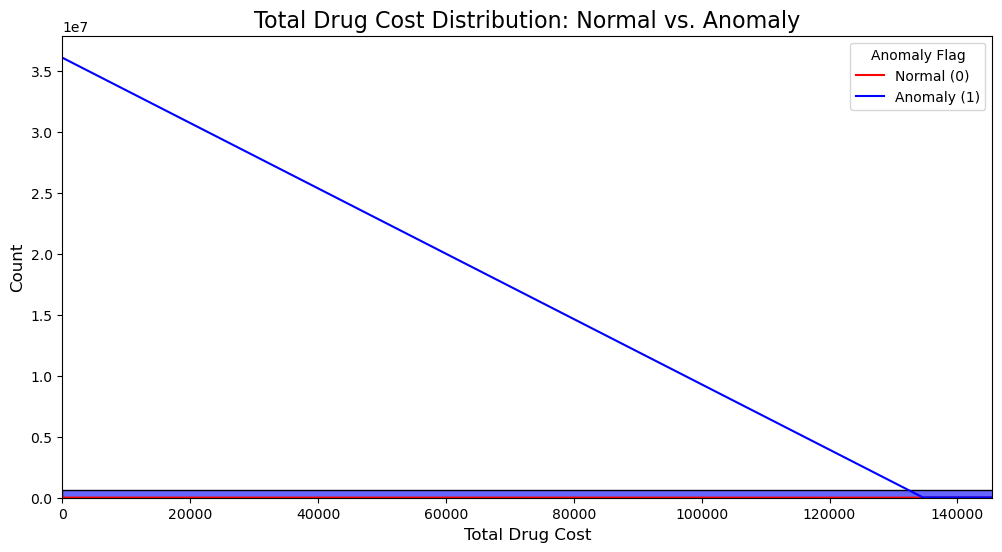

In [32]:
# Visualize Feature Differences for Total Drug Cost
plt.figure(figsize=(12, 6))
sns.histplot(
    data=df, 
    x='Tot_Drug_Cst', 
    hue='is_anomaly_if',       # Isolation Forest binary anomaly flag
    bins=50, 
    kde=True, 
    palette={0: 'blue', 1: 'red'},
    alpha=0.6
)
plt.title('Total Drug Cost Distribution: Normal vs. Anomaly', fontsize=16)
plt.xlabel('Total Drug Cost', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(title='Anomaly Flag', labels=['Normal (0)', 'Anomaly (1)'])
plt.xlim(0, df['Tot_Drug_Cst'].quantile(0.99))  # optional: zoom in on 99th percentile
plt.show()


In [68]:
import pandas as pd
import numpy as np
from IPython.display import display, HTML

# --- extract anomalies using the column created by your pipeline ---
anomalies = df[df["is_anomaly_if"] == 1].copy()

# --- basic checks ---
total_records = len(df)
flagged_count = len(anomalies)
print(f"Total records: {total_records:,}")
print(f"Flagged as anomaly: {flagged_count:,}")
print(f"Anomaly rate: {flagged_count/total_records*100:.2f}%")

# warn if not exactly 6,000
expected = 6000
if flagged_count != expected:
    print(f"Warning: expected {expected:,} anomalies but found {flagged_count:,} (proceeding with actual results).")

# --- Optional: sort anomalies by iso_score (highest first) ---
anomalies = anomalies.sort_values("iso_score", ascending=False)

# --- Display as a scrollable HTML table in the notebook (safe for large output) ---
# Limit columns shown — adjust list to include or exclude columns as needed
display_cols = [
    "Prscrbr_NPI", "Prscrbr_Last_Org_Name", "Prscrbr_First_Name",
    "Prscrbr_State_Abrvtn", "Prscrbr_City", "Gnrc_Name", "Brnd_Name",
    "Tot_Clms", "Tot_Drug_Cst", "Tot_Benes", "GE65_Tot_Benes",
    "Opioid_Flag", "Antibiotics_Flag", "la_Opioid_Flag", "Antipsychotic_Flag",
    "NDC_conflict_Flag", "iso_score"
]
# Keep only columns present in the DataFrame
display_cols = [c for c in display_cols if c in anomalies.columns]

html = anomalies[display_cols].to_html(index=False, classes="table table-sm table-striped")
scrollable = f'<div style="max-height:700px; overflow:auto; padding:6px; border:1px solid #ddd">{html}</div>'
display(HTML(scrollable))

# --- Save to CSV for manual review ---
anomalies.to_csv("flagged_anomalies_if_6000.csv", index=False)
print("Saved flagged anomalies to 'flagged_anomalies_if_6000.csv'")


Total records: 600,000
Flagged as anomaly: 6,000
Anomaly rate: 1.00%


Prscrbr_NPI,Prscrbr_Last_Org_Name,Prscrbr_First_Name,Prscrbr_State_Abrvtn,Prscrbr_City,Gnrc_Name,Brnd_Name,Tot_Clms,Tot_Drug_Cst,Tot_Benes,GE65_Tot_Benes,Opioid_Flag,Antibiotics_Flag,la_Opioid_Flag,Antipsychotic_Flag,NDC_conflict_Flag,iso_score
1023021409,Rasquinha,Clemencia,MN,Golden Valley,Apixaban,Eliquis,2547,1037421.88,366.0,332.0,0,0,0,0,0,1.000000
1013141951,Azzam,Mohannad,AL,Hoover,Apixaban,Eliquis,2060,609504.06,307.0,259.0,0,0,0,0,0,0.907605
1023021409,Rasquinha,Clemencia,MN,Golden Valley,Atorvastatin Calcium,Atorvastatin Calcium,4858,63774.08,758.0,656.0,0,0,0,0,0,0.902464
1003840778,Mays,Ruth,MI,Highland Park,Rsvpref3 Antigen/As01e/Pf,Arexvy,87363,26781952.98,87282.0,85201.0,0,0,0,0,0,0.891066
1023021409,Rasquinha,Clemencia,MN,Golden Valley,Gabapentin,Gabapentin,3530,49825.43,613.0,508.0,0,0,0,0,0,0.890894
1023021409,Rasquinha,Clemencia,MN,Golden Valley,Levothyroxine Sodium,Levothyroxine Sodium,3961,47441.07,622.0,560.0,0,0,0,0,0,0.890894
1023021409,Rasquinha,Clemencia,MN,Golden Valley,Tramadol Hcl,Tramadol Hcl,671,4847.62,195.0,178.0,1,0,1,0,0,0.888472
1003840778,Mays,Ruth,MI,Highland Park,Varicella-Zoster Ge/As01b/Pf,Shingrix,94485,19862186.15,66000.0,60479.0,0,0,0,0,0,0.887199
1023021409,Rasquinha,Clemencia,MN,Golden Valley,Metoprolol Succinate,Metoprolol Succinate,2603,36895.94,451.0,430.0,0,0,0,0,0,0.880756
1023021409,Rasquinha,Clemencia,MN,Golden Valley,Lisinopril,Lisinopril,2634,20886.26,452.0,404.0,0,0,0,0,0,0.880756


Saved flagged anomalies to 'flagged_anomalies_if_6000.csv'


In [33]:
# Filling missing values


In [34]:
prescriber_features = df.groupby('Prscrbr_NPI').agg({
    'Tot_Clms': 'sum',
    'Tot_Drug_Cst': 'sum',
    'Tot_Benes': 'sum',
    'Tot_Day_Suply': 'sum',
    'Brnd_Name': 'nunique',         # Drug diversity
}).reset_index()

prescriber_features

,Prscrbr_NPI,Tot_Clms,Tot_Drug_Cst,Tot_Benes,Tot_Day_Suply,Brnd_Name
0,1003000126,27,8883.72,22.0,590,2
1,1003000142,1769,54440.25,822.0,53183,21
2,1003000167,71,190.08,60.0,328,2
3,1003000423,58,5670.27,22.0,3608,2
4,1003000480,28,409.70,17.0,583,2
...,...,...,...,...,...,...
23679,1023067196,914,85120.00,533.0,44646,14
23680,1023067204,13,1343.82,7.0,542,1
23681,1023067261,166,1336.56,114.0,1135,3
23682,1023067287,222,11640.02,117.0,10316,7
